### Extracción de características
En primer lugar, vamos a realizar la extracción de características con la metodología ISPC, que nos dará la potencia de las bandas de interés para los electrodos seleccionados.

In [8]:

from components_extraction import extract_features_from_epochs
import mne
from pathlib import Path

dir = Path("feature_data")
dir.mkdir(exist_ok=True)

def get_features(subject, session):

    path_input = f'C:\\Users\\aadel\\Desktop\\GCID\\Cuarto\\Segundo Cuatrimestre\\TFG\\python\\preprocessing\\session_{session}\\{subject}_0{session}_epochs_ica_a-epo.fif'

    epochs = mne.read_epochs(path_input, preload=True)

    print(f'Comienza la extracción del usuario::: {subject} de la sesión::: {session}')
    df = extract_features_from_epochs(
    epochs,
    baseline_window=(-10, -9),
    signal_window=(-1, 0)
)
    df.to_csv(dir / f'features_MW_study_session_{session}_subject_{subject}.csv', index=False)
    print("ÉXITO, archivo guardado como: " + f'features_MW_study_session_{session}_subject_{subject}.csv')

In [9]:
import os
import re
sessions =  [1,2]
patron = r".*ica_a-epo\.fif$"
for session in sessions:
    files = os.listdir(f'preprocessing/session_{session}')
    for file in files:
        t = re.compile(patron)
        match = t.search(file)
        if match:
            session = file[5:6]
            subject = file[:3]
            get_features(subject,session)

Reading C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\python\preprocessing\session_1\001_01_epochs_ica_a-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =  -10000.00 ...       0.00 ms
        0 CTF compensation matrices available
Adding metadata with 14 columns
21 matching events found
No baseline correction applied
0 projection items activated
Comienza la extracción del usuario::: 001 de la sesión::: 1

FEATURE EXTRACTION
Epochs: 21
Channels: ['PO7', 'Pz', 'PO8', 'Fz']
Alpha band: 8.5-12 Hz
Theta band: 4-8 Hz
Baseline window: -10 to -9 s
Signal window: -1 to 0 s
⚠️  Warning: Channel Fz/C21 not found

✓ Using channels: {'PO7': 'A10', 'Pz': 'A19', 'PO8': 'B7'}
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

Baseline samples: 257
Signal samples: 257

--- Creating Filters ---
⚠️  Warning: Filter SSE = 39.1677 (should be < 1.0)
   Consider increasing filter length or adjusting parameters
⚠️  Warning: Filter SSE = 28.653

### Entrenamiento con SVM

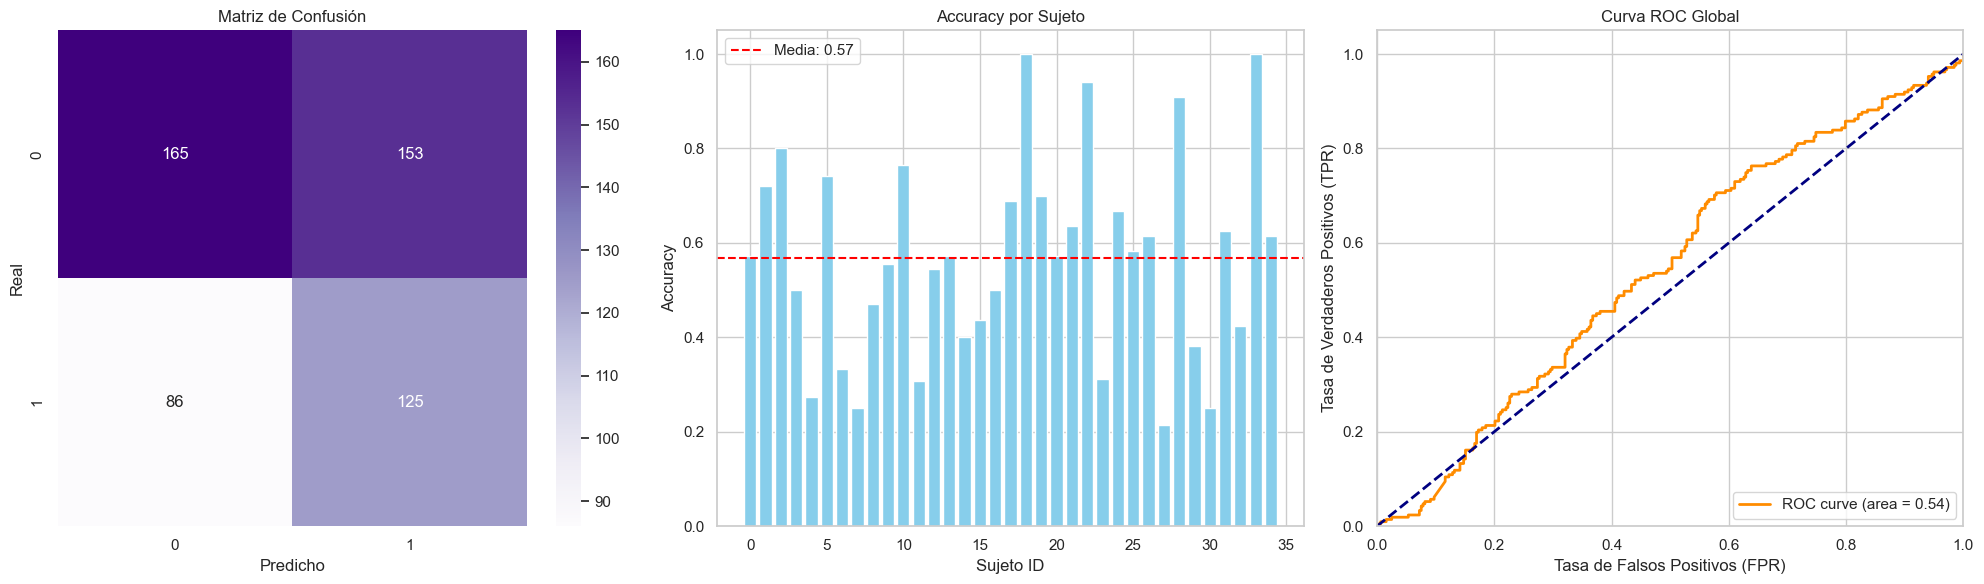


AUC Final: 0.5437
              precision    recall  f1-score   support

           0       0.66      0.52      0.58       318
           1       0.45      0.59      0.51       211

    accuracy                           0.55       529
   macro avg       0.55      0.56      0.55       529
weighted avg       0.57      0.55      0.55       529



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
files = os.listdir("feature_data")

data_list = []
for i, filename in enumerate(files):
    df = pd.read_csv("feature_data/" + filename)
    df['subject_id'] = i
    data_list.append(df)

full_dataset = pd.concat(data_list, ignore_index=True)

# 2. Preparación de variables
X = full_dataset.drop(['label', 'epoch_idx', 'subject_id'], axis=1)
y = full_dataset['label']
groups = full_dataset['subject_id']

# 3. Inicialización de LOGO
logo = LeaveOneGroupOut()
scaler = StandardScaler()

y_true_all = []
y_pred_all = []
y_probs_all = []  # Para ROC
subject_accuracies = []


# 4. Bucle de Validación Cruzada por Grupo (Sujeto)
for train_index, test_index in logo.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Escalado (Previene Data Leakage entre sujetos)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelo SVM (probability=True para poder graficar curva ROC después)
    model = SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced')
    model.fit(X_train_scaled, y_train)

    # Predicción
    preds = model.predict(X_test_scaled)

    # Guardar resultados globales y por sujeto
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)
    y_probs_all.extend(model.predict_proba(X_test_scaled)[:, 1])
    subject_accuracies.append(accuracy_score(y_test, preds))

# --- 5. VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# A. Matriz de Confusión
cm = confusion_matrix(y_true_all, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# B. Precisión por Sujeto
axes[1].bar(range(len(subject_accuracies)), subject_accuracies, color='skyblue')
axes[1].axhline(np.mean(subject_accuracies), color='red', linestyle='--', label=f'Media: {np.mean(subject_accuracies):.2f}')
axes[1].set_title('Accuracy por Sujeto')
axes[1].set_xlabel('Sujeto ID')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# C. Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_true_all, y_probs_all)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[2].set_title('Curva ROC Global')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Resumen numérico
print(f"\nAUC Final: {roc_auc:.4f}")
print(classification_report(y_true_all, y_pred_all))

In [34]:
import pandas as pd
files = os.listdir("features_data")

data_list = []
for filename in files:
    print(filename)
    df = pd.read_csv("features_data/" + filename)
    data_list.append(df)

full_dataset = pd.concat(data_list, ignore_index=True)
full_dataset.info()

features_MW_study_session_1_subject_001.csv
features_MW_study_session_1_subject_002.csv
features_MW_study_session_1_subject_003.csv
features_MW_study_session_1_subject_004.csv
features_MW_study_session_1_subject_005.csv
features_MW_study_session_1_subject_006.csv
features_MW_study_session_1_subject_007.csv
features_MW_study_session_1_subject_008.csv
features_MW_study_session_1_subject_010.csv
features_MW_study_session_1_subject_011.csv
features_MW_study_session_1_subject_012.csv
features_MW_study_session_1_subject_013.csv
features_MW_study_session_1_subject_015.csv
features_MW_study_session_1_subject_016.csv
features_MW_study_session_1_subject_018.csv
features_MW_study_session_1_subject_019.csv
features_MW_study_session_1_subject_020.csv
features_MW_study_session_1_subject_021.csv
features_MW_study_session_1_subject_022.csv
features_MW_study_session_1_subject_023.csv
features_MW_study_session_1_subject_024.csv
features_MW_study_session_2_subject_001.csv
features_MW_study_session_2_subj